In [26]:
import numpy as np   # for analysis part
import pandas as pd   # for analysis part
import matplotlib.pyplot as plt     # for visualization part
import seaborn as sn        # for visualization part

In [27]:
pd.set_option("display.max_columns", None)    # tells Pandas not to hide any columns when displaying a DataFrame. It’s mainly for convenience when exploring wide datasets

In [28]:
sn.set_style("whitegrid")    #  used to make your plots cleaner and easier to interpret by adding gridlines on a white background.

In [29]:
data = pd.read_csv("German Credit Risk - with Target\german_credit_data.csv")

In [30]:
data.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [31]:
data.describe()

,Unnamed: 0,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


In [32]:
data['Credit amount'].describe()

count     1000.000000
mean      3271.258000
std       2822.736876
min        250.000000
25%       1365.500000
50%       2319.500000
75%       3972.250000
max      18424.000000
Name: Credit amount, dtype: float64

In [33]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [34]:
data['Age'] = data['Age'].astype(int)

In [35]:
data = data.dropna().reset_index(drop=True)

In [36]:
data

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,4,53,male,2,free,little,little,4870,24,car,bad
3,7,35,male,3,rent,little,moderate,6948,36,car,good
4,9,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
517,989,48,male,1,own,little,moderate,1743,24,radio/TV,good
518,993,30,male,3,own,little,little,3959,36,furniture/equipment,good
519,996,40,male,3,own,little,little,3857,30,car,good
520,998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [37]:
data.drop(columns = 'Unnamed: 0', inplace = True)

In [38]:
data.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

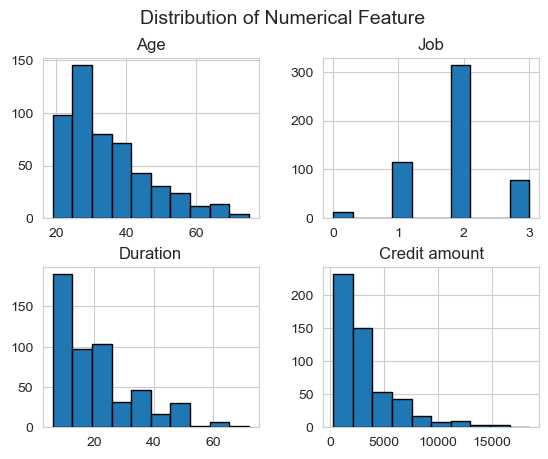

In [39]:
data[['Age', 'Job', 'Duration', 'Credit amount']].hist(bins = 10, edgecolor = 'black')   #  "bins" means the number of intervals (or buckets) your data is grouped into for the histogram.
plt.suptitle('Distribution of Numerical Feature', fontsize = 14)
plt.show()

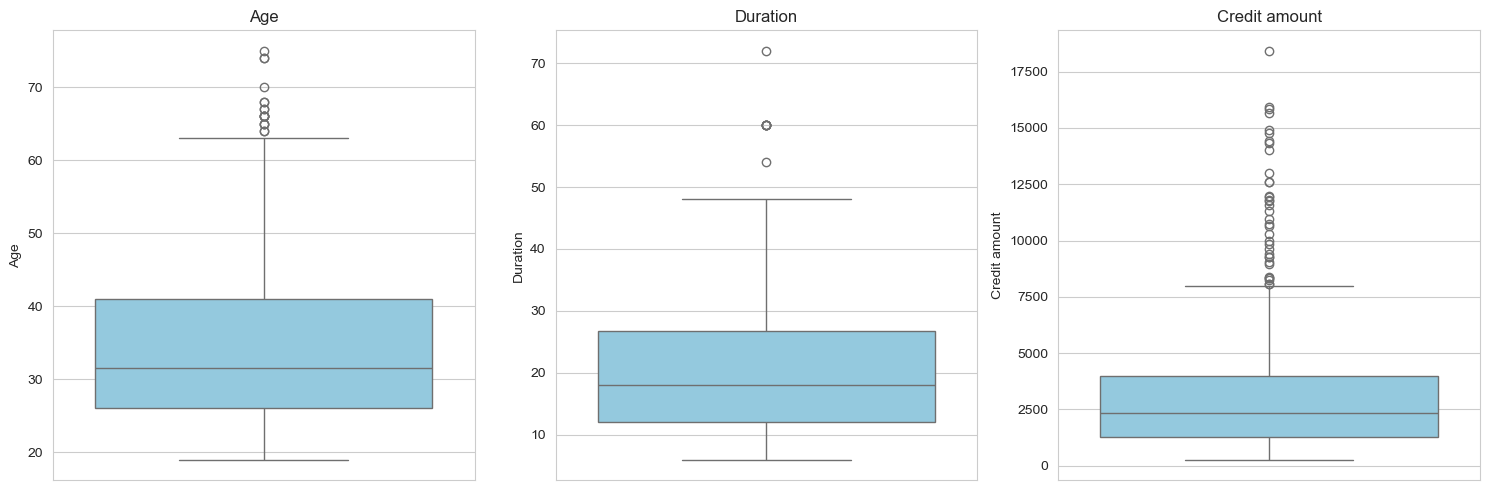

"\nenumerate([...])  \nThis takes the list ['Age', 'Duration', 'Credit amount'] and returns pairs of (index, value):\n(0, 'Age')\n(1, 'Duration')\n(2, 'Credit amount')\n\nfor i, col in enumerate(...)\ni → the index (0, 1, 2)\ncol → the actual string value ('Age', 'Duration', 'Credit amount')\n\nplt.subplot(1, 3, i+1)\nThis creates a subplot grid with 1 row and 3 columns.\ni+1 selects which subplot to activate (subplot numbering starts at 1, not 0).\n\nWhen i=0, it activates subplot 1 (for 'Age').\nWhen i=1, it activates subplot 2 (for 'Duration').\nWhen i=2, it activates subplot 3 (for 'Credit amount').\n\nWhat values are extracted?\nFrom the list, the column names 'Age', 'Duration', and 'Credit amount' are extracted one by one into col.\n"

In [40]:
plt.figure(figsize = (15, 5))

for i, col in enumerate(['Age', 'Duration','Credit amount']):
    plt.subplot(1, 3, i+1)
    sn.boxplot(y = data[col], color = 'skyblue')
    plt.title(col)

plt.tight_layout()
plt.show()

"""
enumerate([...])  
This takes the list ['Age', 'Duration', 'Credit amount'] and returns pairs of (index, value):
(0, 'Age')
(1, 'Duration')
(2, 'Credit amount')

for i, col in enumerate(...)
i → the index (0, 1, 2)
col → the actual string value ('Age', 'Duration', 'Credit amount')

plt.subplot(1, 3, i+1)
This creates a subplot grid with 1 row and 3 columns.
i+1 selects which subplot to activate (subplot numbering starts at 1, not 0).

When i=0, it activates subplot 1 (for 'Age').
When i=1, it activates subplot 2 (for 'Duration').
When i=2, it activates subplot 3 (for 'Credit amount').

What values are extracted?
From the list, the column names 'Age', 'Duration', and 'Credit amount' are extracted one by one into col.
"""

In [41]:
data.query("Duration >= 60")

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
18,63,male,2,own,little,little,6836,60,business,bad
176,24,female,3,own,moderate,moderate,7408,60,car,bad
199,60,female,3,free,moderate,moderate,14782,60,vacation/others,bad
358,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad
378,27,male,3,own,little,moderate,14027,60,car,bad
489,42,male,2,free,little,moderate,6288,60,education,bad
507,36,male,2,rent,little,little,7297,60,business,bad


In [42]:
Categorical_cols = ["Sex", "Job", "Housing", "Saving accounts", "Checking account", "Purpose"]

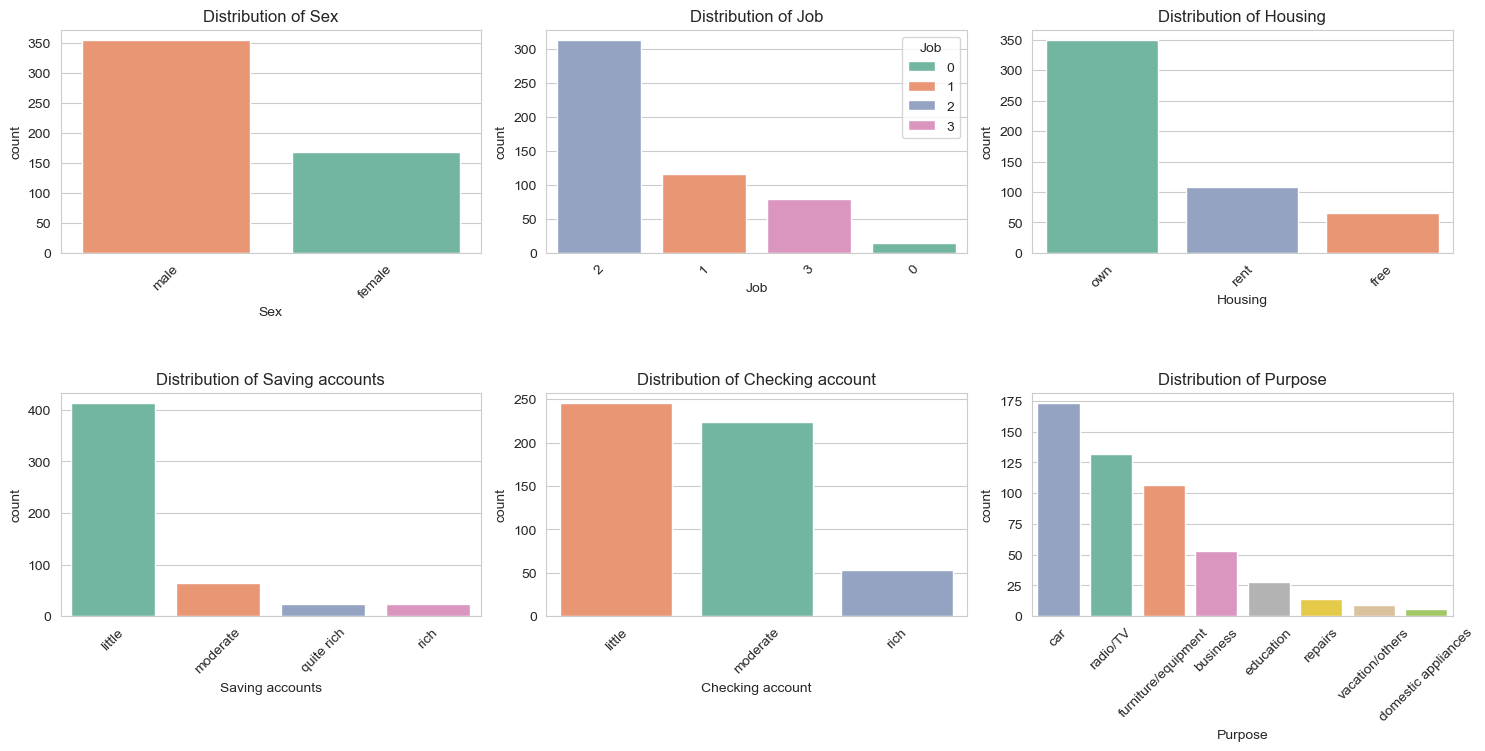

In [43]:
plt.figure(figsize=(15,10))
for i, col in enumerate(Categorical_cols):
    plt.subplot(3,3,i+1)
    sn.countplot(data = data, x = col, hue = col, palette = 'Set2', order = data[col].value_counts().index)  # Returns the list of unique values (categories) 
                                                                                                             # sorted by frequency (highest count first).
    # When you pass this order into a Seaborn countplot, it ensures that the bars are displayed in descending order of frequency. So the most common category appears first, then the next, and so on
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()
    


In [44]:
corr = data[["Age", "Job", "Credit amount", "Duration"]].corr()    #the double brackets are used to select multiple columns at once, so you can run .corr() on a subset of your dataset instead of the whole thing.

In [45]:
corr

,Age,Job,Credit amount,Duration
Age,1.000000,0.039771,0.082014,0.001549
Job,0.039771,1.000000,0.334721,0.200794
Credit amount,0.082014,0.334721,1.000000,0.613298
Duration,0.001549,0.200794,0.613298,1.000000


Heatmap

A heatmap is a type of data visualization where values in a matrix (rows × columns) are represented using color intensity instead of numbers. In Seaborn, you create one with sns.heatmap().

🔎 What a heatmap shows
Each cell in the matrix corresponds to a value.
The color of the cell encodes the magnitude of that value (e.g., darker = higher, lighter = lower).
It’s especially useful for spotting patterns, correlations, and clusters in data at a glance.

📍 Common Uses
Correlation matrices: Visualize relationships between variables.
Confusion matrices: Show classification performance in machine learning.
General 2D data: Any tabular data where magnitude matters.

✨ Why it’s powerful
Numbers in a correlation matrix can be hard to interpret quickly.
A heatmap makes strong positive/negative correlations pop visually.
It’s widely used in EDA (Exploratory Data Analysis) to understand datasets before modeling.

👉 In short: sns.heatmap() turns a numeric matrix into a color-coded visual grid, making relationships and patterns easy to spot.

# Heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()
    
annot=True → shows the actual correlation values inside each cell.
cmap='coolwarm' → sets the color palette (blue = low, red = high).

when annot=False
Default behavior: annot=False (if you don’t specify anything).
This means the heatmap will only show colors to represent values.
No numbers will be printed inside the cells.

# Heatmap without annotations
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.show()
You’ll see a grid of colored squares.

The colors indicate the strength of correlation, but you won’t see the actual numeric values.

✨ Why use annot=False?
Cleaner look when you only care about visual patterns.
Useful if the matrix is large (too many numbers would clutter the plot).

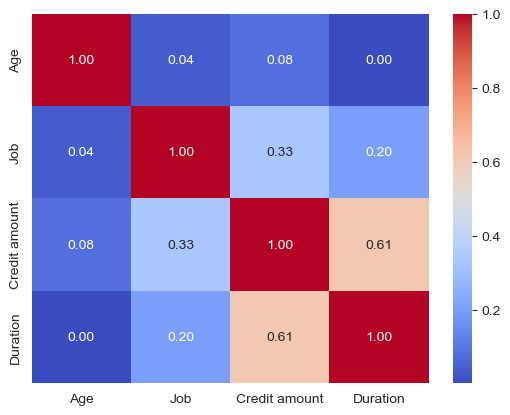

In [46]:
sn.heatmap(corr, annot = True, cmap = 'coolwarm', fmt = '.2f')
plt.show()

In [47]:
data.groupby('Job')['Credit amount'].mean()


#df.groupby('Job')
#This groups the DataFrame df by the values in the column "Job".
#Each unique job category becomes a group.

#['Credit amount']
#After grouping, we select the "Credit amount" column.
#So now we’re focusing only on the credit amounts within each job group.

#.mean()
#Finally, we apply the aggregation function .mean().
#This calculates the average credit amount for each job category.


Job
0    1767.857143
1    2250.715517
2    3129.130990
3    5648.784810
Name: Credit amount, dtype: float64

In [48]:
data.groupby('Sex')['Credit amount'].mean()

Sex
female    2937.202381
male      3440.833333
Name: Credit amount, dtype: float64

In [49]:
pd.pivot_table(data, index = 'Housing', columns = 'Purpose', values = 'Credit amount')

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4705.000000,5180.314286,NaN,5314.250000,4419.444444,2097.000000,1190.0,7842.666667
own,3725.973684,3120.485437,1333.5,2625.076923,3031.100000,2307.613861,2993.5,10321.833333
rent,6180.833333,3398.285714,NaN,2627.857143,2890.285714,2138.000000,2384.0,NaN


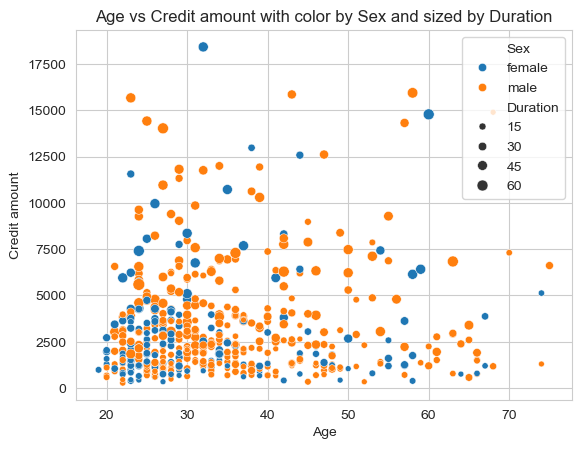

In [50]:
sn.scatterplot(data = data, x = 'Age', y = 'Credit amount', hue = 'Sex', size = 'Duration')
plt.title("Age vs Credit amount with color by Sex and sized by Duration")
plt.show()

In [51]:
data.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

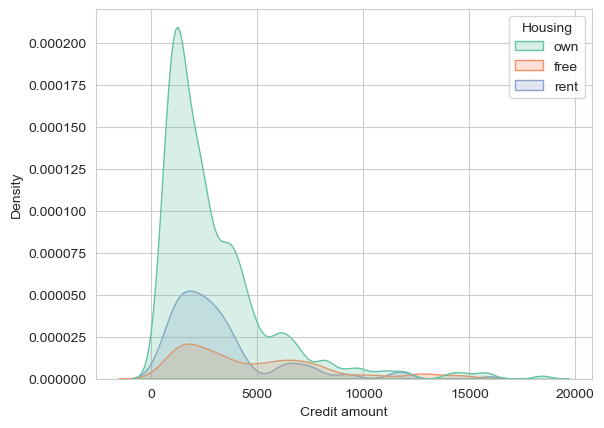

In [52]:
sn.kdeplot(data, x = 'Credit amount', hue = 'Housing', fill = True, bw_adjust = 0.5, palette = 'Set2')

plt.show()

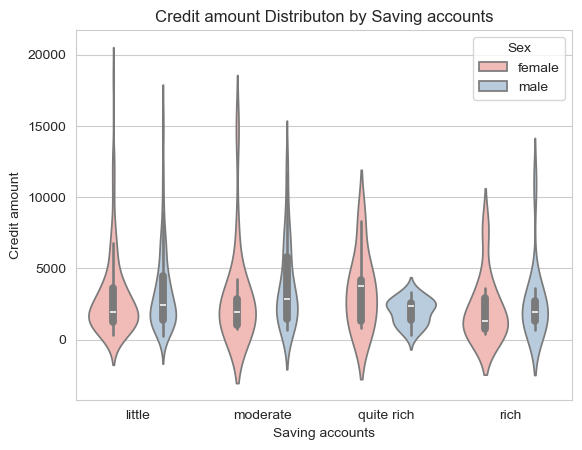

In [53]:
sn.violinplot(data = data, x = 'Saving accounts', y = 'Credit amount',hue = 'Sex', palette = 'Pastel1')
plt.title('Credit amount Distributon by Saving accounts')
plt.show()

In [54]:
data['Risk'].value_counts(normalize = True) * 100

# Normally, df['Any_column'].value_counts() gives you the frequency counts of each unique value in that column.

# Adding normalize=True changes the behavior: instead of raw counts, it returns relative frequencies (proportions).

# In other words, each count is divided by the total number of rows, so the output is between 0 and 1.

# Since proportions are between 0 and 1, multiplying by 100 converts them into percentages.

Risk
good    55.747126
bad     44.252874
Name: proportion, dtype: float64

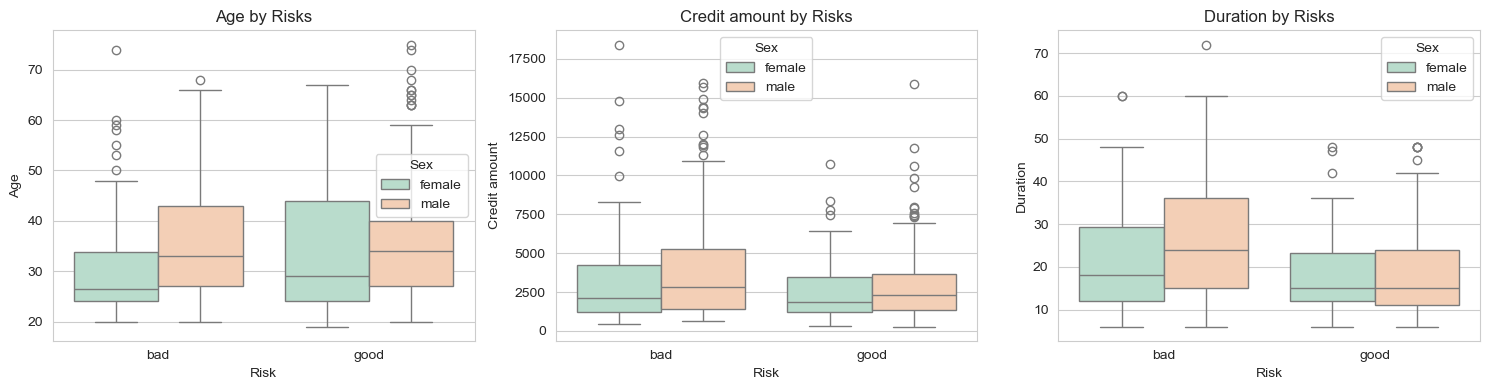

In [56]:
plt.figure(figsize= (15, 4))
for i, col in enumerate(['Age', 'Credit amount', 'Duration']):
    plt.subplot(1, 3, i+1)
    sn.boxplot(data = data, x = 'Risk', y = col, hue = 'Sex', palette = 'Pastel2')
    plt.title(f"{col} by Risks")

plt.tight_layout()
plt.show()

In [57]:
data.groupby('Risk')[['Age', 'Credit amount', 'Duration']].mean()

,Age,Credit amount,Duration
Risk,,,
bad,34.147186,3881.090909,25.445887
good,35.477663,2800.594502,18.079038


In [58]:
Categorical_cols

['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

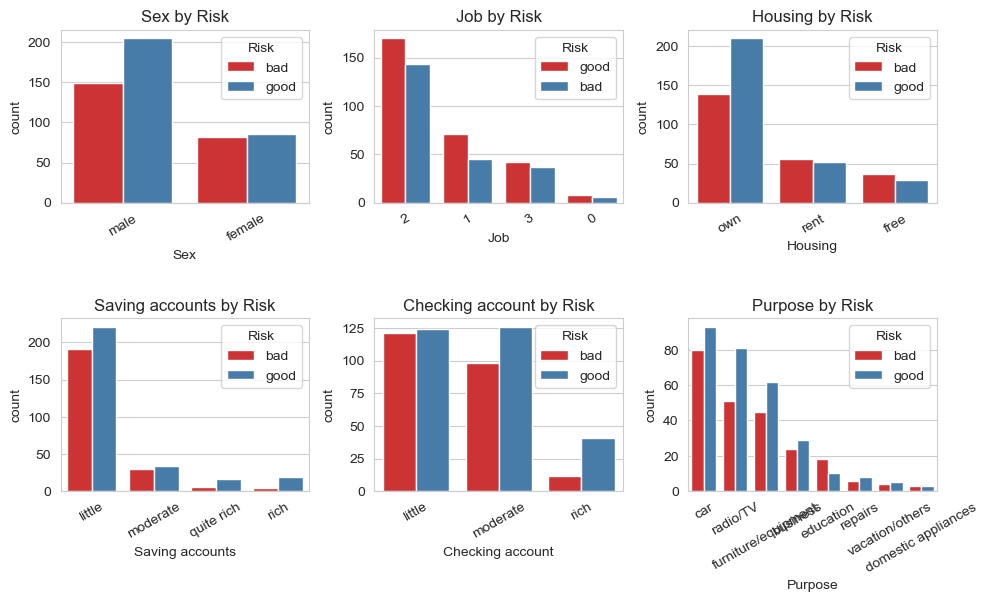

In [59]:
plt.figure(figsize= (10, 8))
for i, cols in enumerate(Categorical_cols):
    plt.subplot(3,3,i+1)
    sn.countplot(data = data, x = cols, hue = 'Risk', palette = 'Set1', order = data[cols].value_counts().index)
    plt.title(f"{cols} by Risk")
    plt.xticks(rotation = 30)
plt.tight_layout()
plt.show()

In [60]:
data.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [61]:
feature = ['Age', 'Sex', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration']

In [62]:
target = 'Risk'

In [70]:
data_model = data[ feature + [target]].copy()

In [64]:
data_model.head()

,Age,Sex,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,female,own,little,moderate,5951,48,bad
1,45,male,free,little,little,7882,42,good
2,53,male,free,little,little,4870,24,bad
3,35,male,rent,little,moderate,6948,36,good
4,28,male,own,little,moderate,5234,30,bad


In [65]:
from sklearn.preprocessing import LabelEncoder
import joblib

In [66]:
"""
Concept
Parallel: The engine that runs tasks in parallel across multiple CPU cores.
delayed: A wrapper that tells Parallel what function to run later and with which arguments.

Together, they let you write loops that look normal but execute in parallel.

⚙️ How It Works
You define a function that does some work.
You wrap calls to that function with delayed().
This doesn’t execute immediately — it just builds a “task description.”
You pass those delayed tasks into Parallel().
Parallel distributes them across CPU cores and runs them simultaneously.
"""

from joblib import Parallel, delayed
import time

def Square(x):
    time.sleep(1)
    return x*x

result = Parallel(n_jobs=5)(delayed(Square)(i) for i in range(10))
print(result)

# What happens:
# Normally, squaring 10 numbers with a 1-second delay each would take ~10 seconds.
# With n_jobs=4, joblib runs 4 tasks at once, so it finishes in about 3 seconds.


# Key Notes
# n_jobs=-1 → use all available cores.
# Best for CPU-bound tasks (heavy computation).
# Not ideal for I/O-bound tasks (like waiting on network requests).
# Results are collected in the same order as the input sequence, even though tasks finish at different times.

# So in short:
# delayed = “don’t run this yet, just prepare the task.”
# Parallel = “run all these prepared tasks across multiple cores and give me the results."


[0, 1, 4, 9, 16, 25, 36, 49, 64, 81]


In [67]:
cat_cols = data_model.select_dtypes(include = 'object').columns.drop('Risk')

In [68]:
le_dict = {}

In [69]:
cat_cols

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account'], dtype='object')

In [71]:
for col in cat_cols:
    le = LabelEncoder()
    data_model[col] = le.fit_transform(data_model[col])
    le_dict[col] = le
    joblib.dump(le, f"{col}_encoder.pkl")

In [72]:
le_target = LabelEncoder()

In [73]:
target

'Risk'

In [74]:
data_model[target] = le_target.fit_transform(data_model[target])

In [77]:
data_model[target].value_counts()

Risk
1    291
0    231
Name: count, dtype: int64

In [78]:
joblib.dump(le_target, "target_encoder.pkl")

['target_encoder.pkl']

In [79]:
data_model.head()    # all numeric value

,Age,Sex,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,0,1,0,1,5951,48,0
1,45,1,0,0,0,7882,42,1
2,53,1,0,0,0,4870,24,0
3,35,1,2,0,1,6948,36,1
4,28,1,1,0,1,5234,30,0


In [80]:
from sklearn.model_selection import train_test_split

In [85]:
X = data_model.drop(target, axis=1)

In [87]:
y = data_model[target]

In [90]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify = y, random_state=1)

In [91]:
X_train.shape

(417, 7)

In [92]:
X_test.shape

(105, 7)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

In [100]:
def train_model(model, param_grid, X_train, y_train , X_test, y_test):
    grid = GridSearchCV(model, param_grid, cv=5, scoring = "accuracy", n_jobs=-1)
    grid.fit(X_train,y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    return best_model, acc, grid.best_params_

In [101]:
dt = DecisionTreeClassifier(random_state=1, class_weight="balanced")
dt_param_grid = {
    "max_depth" : [3, 5, 7, 10, None],
    "min_samples_split" : [2, 5, 10],
    "min_samples_leaf" : [1, 2, 4]
}

In [102]:
best_dt, acc_dt, params_dt = train_model(dt, dt_param_grid, X_train, y_train, X_test, y_test)

In [103]:
print("Decision Tree Accuracy", acc_dt)

Decision Tree Accuracy 0.5904761904761905


In [104]:
print("Best parameters", params_dt)

Best parameters {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10}


In [105]:
# RandomForestClassifier
rf = RandomForestClassifier(random_state=1, class_weight="balanced", n_jobs=-1)

In [106]:
rf_param_grid = {
    "n_estimators" : [100, 200],
    "max_depth" : [5, 7, 10, None],
    "min_samples_split" : [2, 5, 10],
    "min_samples_leaf" : [1, 2, 4]
}

In [109]:
best_rf, acc_rf, params_rf = train_model(rf, rf_param_grid, X_train, y_train, X_test, y_test)

In [110]:
print("Random Forest Accuracy", acc_rf)

Random Forest Accuracy 0.6476190476190476


In [111]:
print("Best params", params_rf)

Best params {'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [112]:
et = ExtraTreesClassifier(random_state=1, class_weight="balanced", n_jobs=-1)

In [113]:
et_param_grid = {
    "n_estimators" : [100, 200],
    "max_depth" : [5, 7, 10, None],
    "min_samples_split" : [2, 5, 10],
    "min_samples_leaf" : [1, 2, 4]
}

In [114]:
best_et, acc_et, params_et = train_model(et, et_param_grid,  X_train, y_train, X_test, y_test)

In [115]:
print("Extra Tree Accuracy", acc_et)

Extra Tree Accuracy 0.6571428571428571


In [116]:
print("Best params", params_et)

Best params {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}


In [117]:
xgb = XGBClassifier(random_state=1, scale_pos_weight = (y_train == 0).sum() /(y_train == 1).sum(), use_label_encoder=False, eval_metric="logloss")

In [118]:
xgb_param_grid = {
    "n_estimators" : [100, 200],
    "max_depth" : [3, 5, 7],
    "learning_rate" : [0.01, 0.1, 0.2],
    "subsample" : [0.7, 1],
    "colsample_bytree" : [0.7, 1]
}

In [119]:
best_xgb, acc_xgb, params_xgb = train_model(xgb, xgb_param_grid,  X_train, y_train, X_test, y_test)

In [120]:
print("XGB Accuracy", acc_xgb)

XGB Accuracy 0.6571428571428571


In [121]:
print("Best params",params_xgb)

Best params {'colsample_bytree': 0.7, 'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1}


In [122]:
best_et.predict(X_test)

array([1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1,
       1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1])

In [123]:
joblib.dump(best_et, "extra_trees_credit_model.pkl")

['extra_trees_credit_model.pkl']

In [124]:
X_train.head()

,Age,Sex,Housing,Saving accounts,Checking account,Credit amount,Duration
295,29,0,1,0,2,683,6
171,28,1,1,3,0,2659,18
22,33,0,1,0,2,1474,12
339,38,1,1,0,1,1308,15
173,31,1,1,0,2,4473,36
